In [1]:
%load_ext autoreload
%autoreload 2

import psycopg
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from redshift_etl.scripts.config_helper import get_config

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Connect to Redshift
config = get_config()
HOST = config.get('CLUSTER','HOST')
DB_NAME = config.get('CLUSTER','DB_NAME')
DB_USER = config.get('CLUSTER','DB_USER')
DB_PASSWORD = config.get('CLUSTER','DB_PASSWORD')
DB_PORT = config.get('CLUSTER','DB_PORT')

conn = psycopg.connect(
        host=HOST,
        dbname=DB_NAME,
        user=DB_USER,
        password=DB_PASSWORD,
        port=DB_PORT,
        client_encoding='utf8'
    )

def run_query(sql):
    """Execute a query and return the results as a pandas DataFrame."""
    with conn.cursor() as cur:
        cur.execute(sql)
        columns = [desc[0] for desc in cur.description]
        results = cur.fetchall()
        return pd.DataFrame(results, columns=columns)

# Sparkify Analytics Dashboard
Theis notebook presents analytical queries against the Sparkify data warehouse toe demonstrate teh star schema supports real business questions

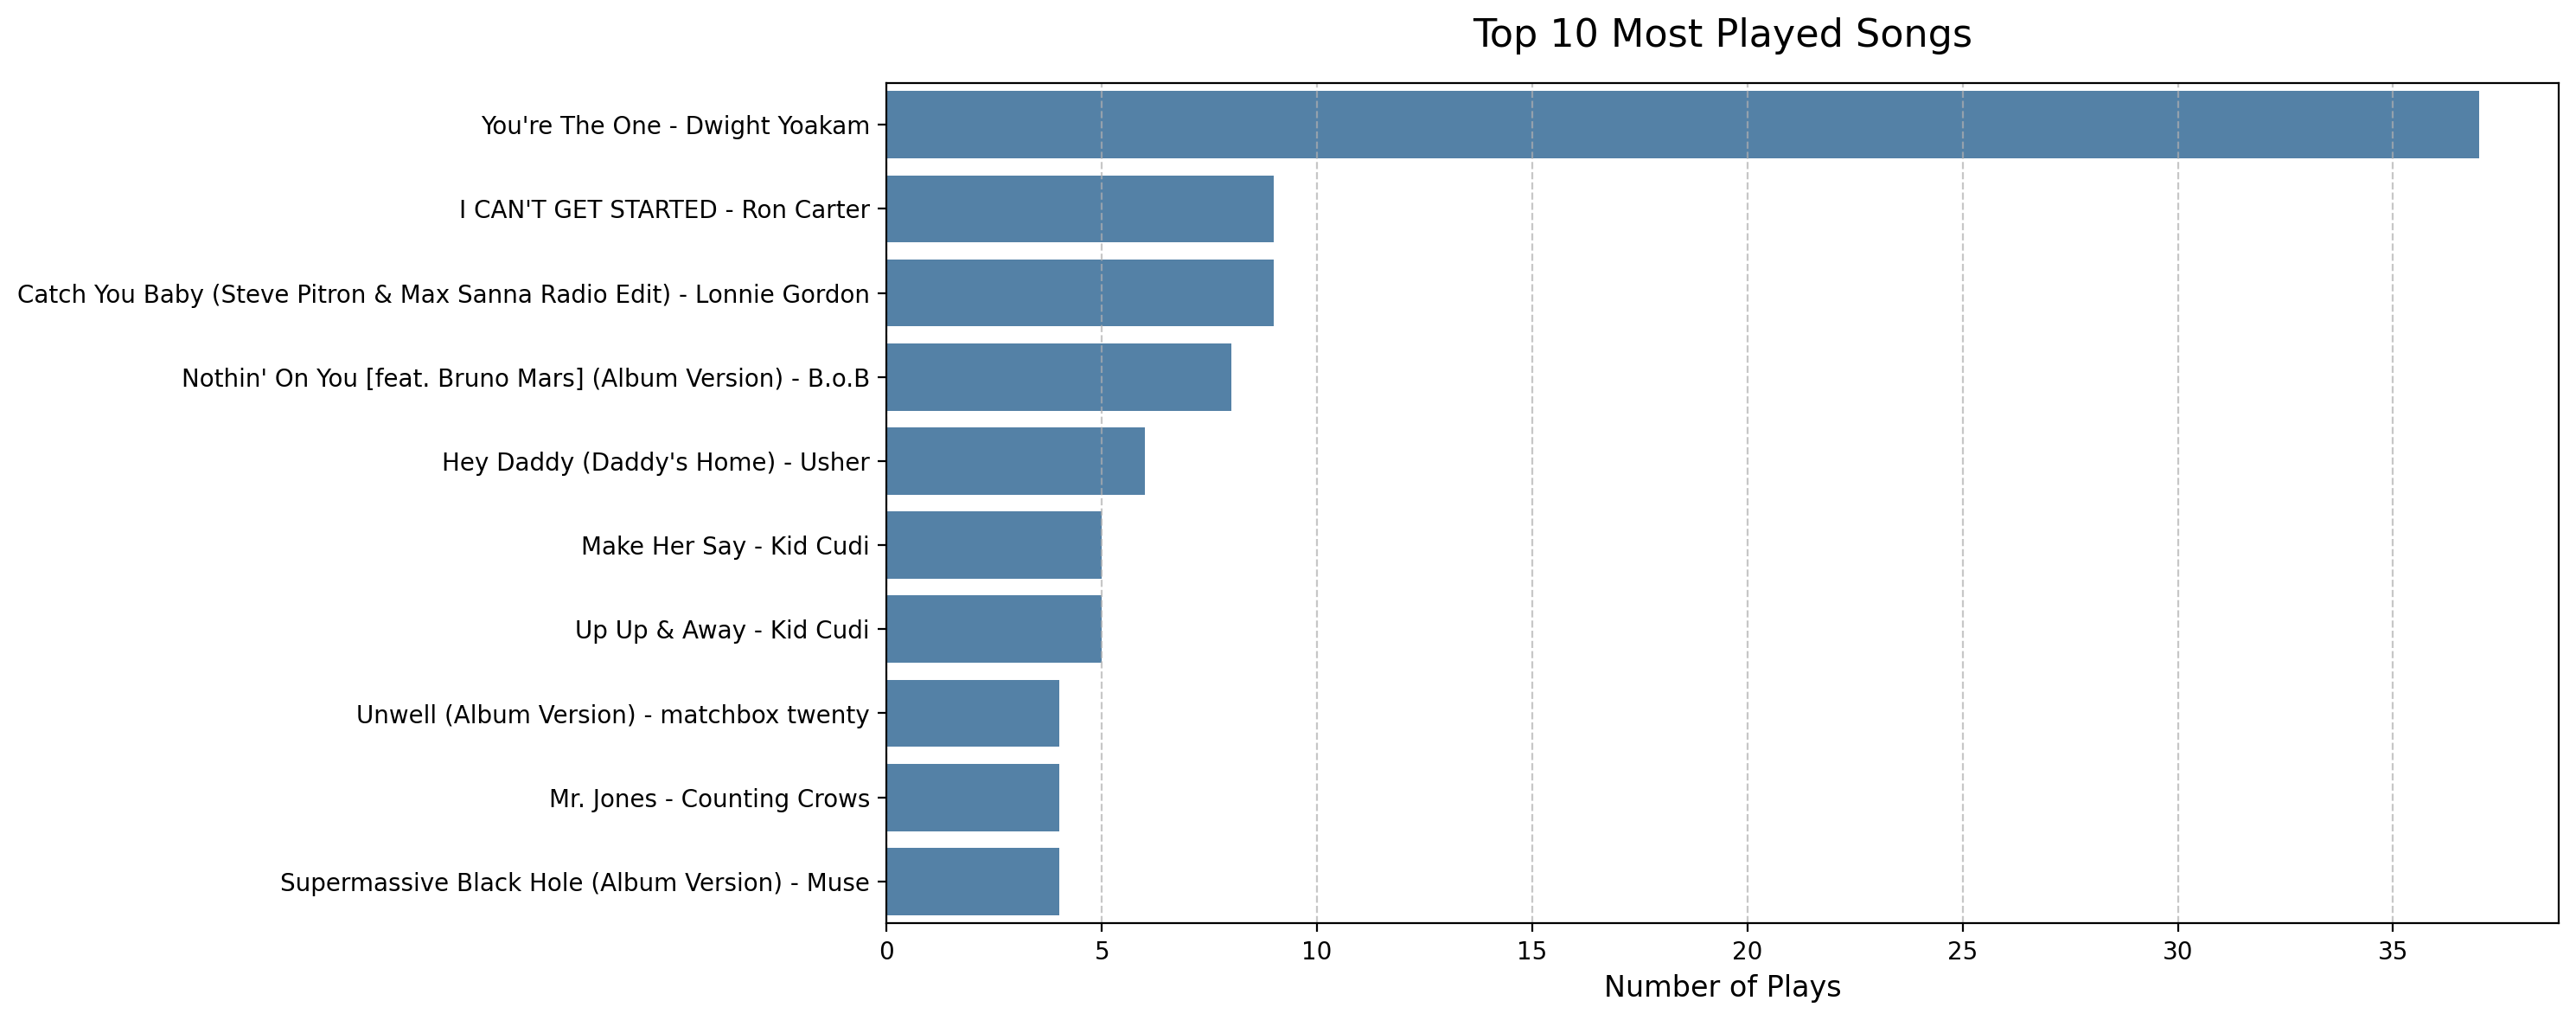

,song_title,artist_name,play_count
0,You're The One,Dwight Yoakam,37
1,I CAN'T GET STARTED,Ron Carter,9
2,Catch You Baby (Steve Pitron & Max Sanna Radio...,Lonnie Gordon,9
3,Nothin' On You [feat. Bruno Mars] (Album Version),B.o.B,8
4,Hey Daddy (Daddy's Home),Usher,6
5,Make Her Say,Kid Cudi,5
6,Up Up & Away,Kid Cudi,5
7,Unwell (Album Version),matchbox twenty,4
8,Mr. Jones,Counting Crows,4
9,Supermassive Black Hole (Album Version),Muse,4


In [2]:
top_songs = run_query("""
    SELECT s.title AS song_title,
           a.name AS artist_name,
           COUNT(*) AS play_count
    FROM songplays sp
    JOIN songs s ON sp.song_id = s.song_id
    JOIN artists a ON sp.artist_id = a.artist_id
    GROUP BY s.title, a.name
    ORDER BY play_count DESC
    LIMIT 10;
""")

plt.figure(figsize=(15,6))

# Create a combined lable for the y-axis
top_songs['song_and_artist'] = top_songs['song_title'] + ' - '+ top_songs['artist_name']

# Create a Seaborn horizontal barplot
sns.barplot(
    data=top_songs,
    x='play_count',
    y='song_and_artist',
    color='steelblue'
)

# Set the title and labels
plt.title('Top 10 Most Played Songs', fontsize=16, pad=15)
plt.xlabel('Number of Plays', fontsize=12)
plt.ylabel('')

# Add gridlines on the x-axis for easier reading
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Adjust layout and display
plt.tight_layout()
plt.show()

# Drop the temporary colum sont_and_artist
top_songs.drop(columns=['song_and_artist'], inplace=True)
top_songs

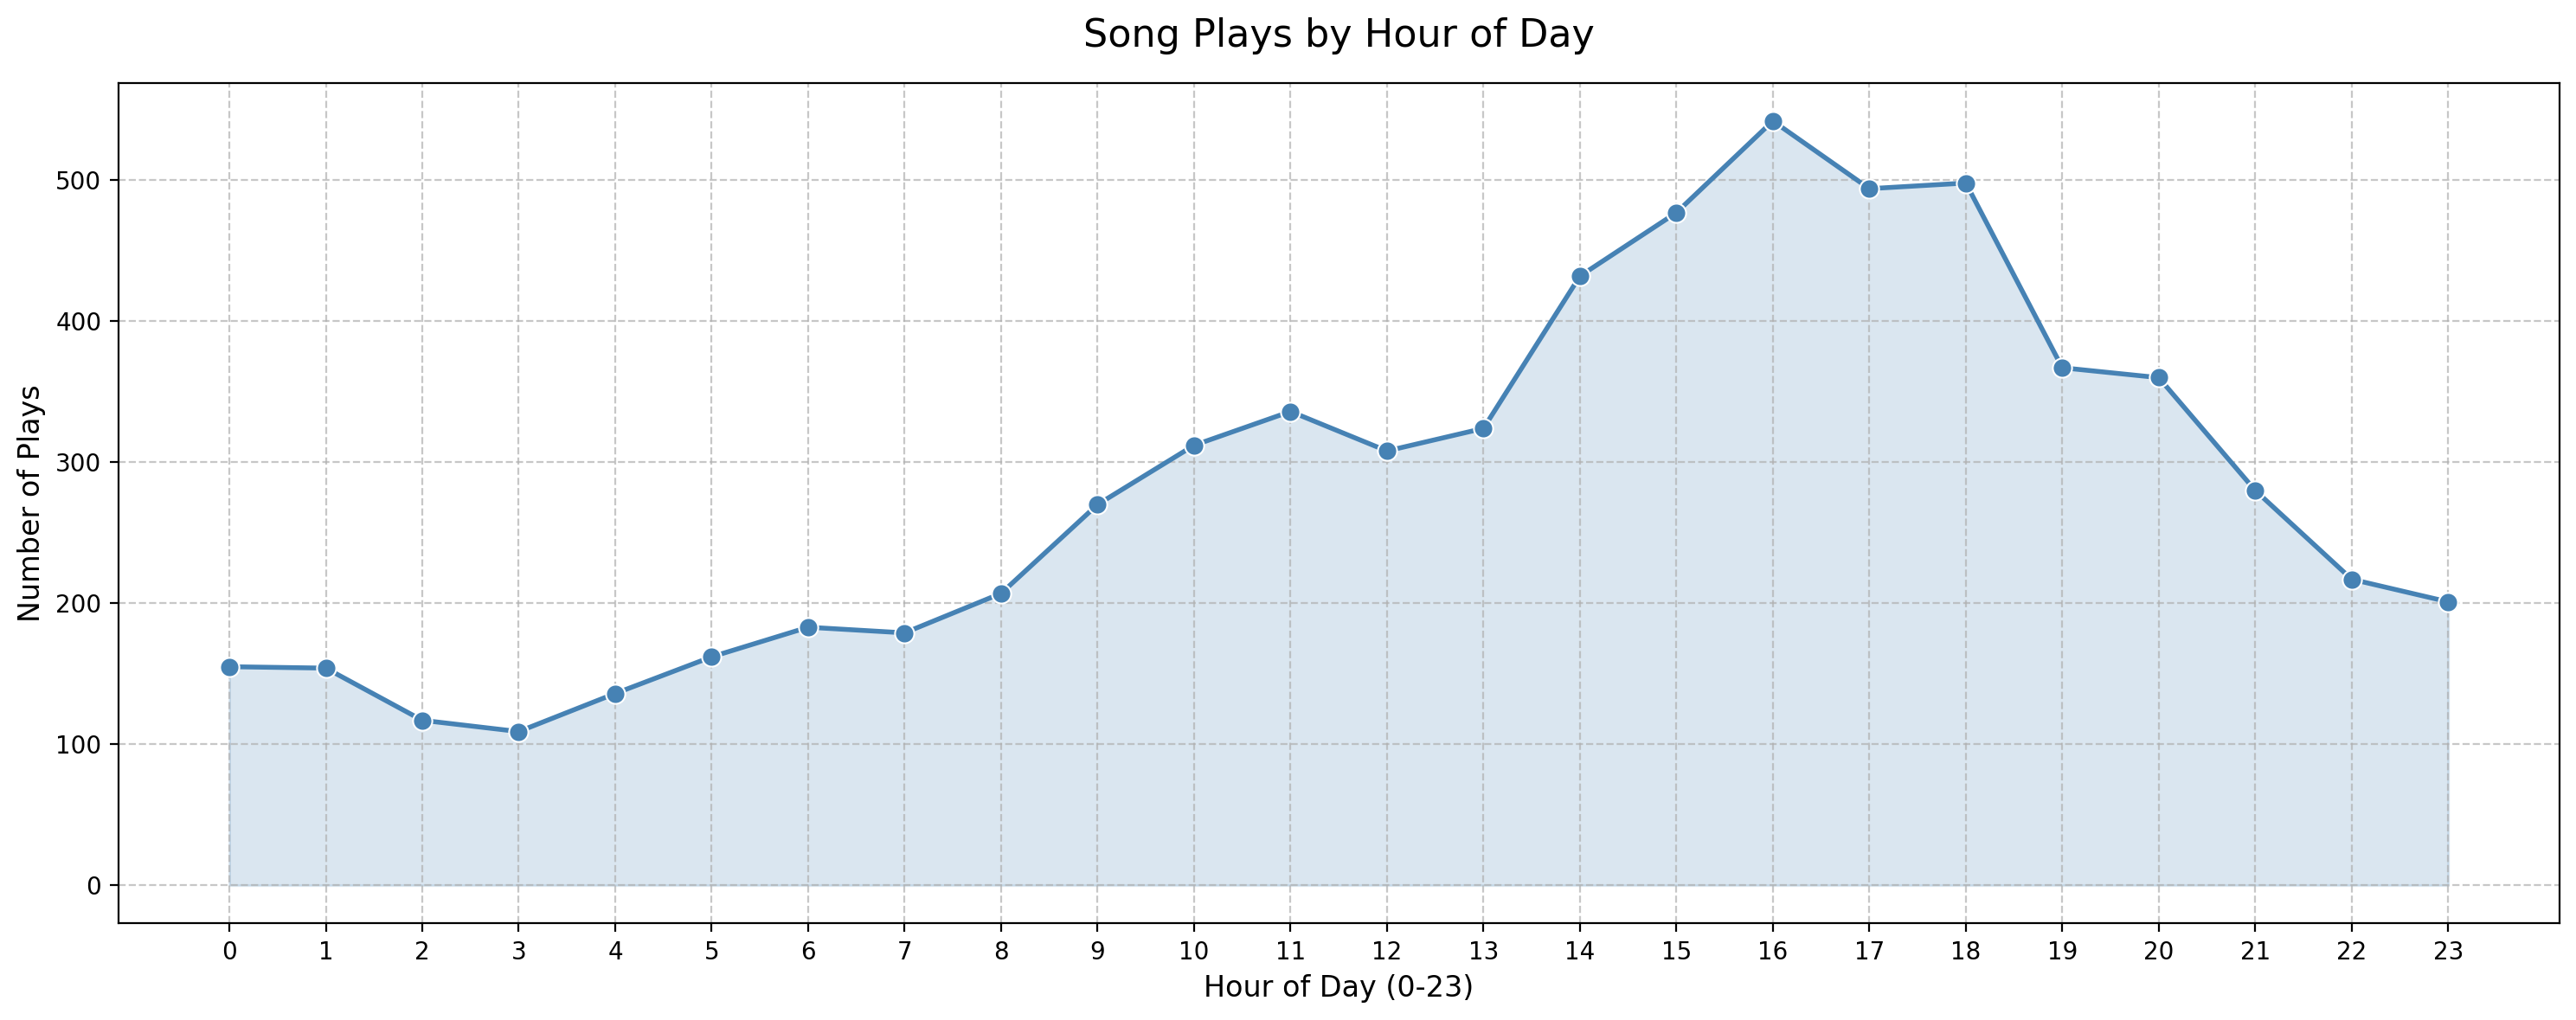

In [3]:
# Usage by Hour of Day
hourly_usage = run_query("""
    SELECT t.hour,
           COUNT(*) AS play_count
    FROM songplays sp
    JOIN time t ON sp.start_time = t.start_time
    GROUP BY t.hour
    ORDER BY t.hour;
""")

plt.figure(figsize=(15,6))

# Line plot for showing changes over continuous time
sns.lineplot(
    data=hourly_usage,
    x='hour',
    y='play_count',
    color='steelblue',
    linewidth=2,
    marker='o', # Adds a dot for each specific hour
    markersize=8
)

# Fill the area under the line to make it visually heavier
plt.fill_between(hourly_usage['hour'], hourly_usage['play_count'], color='steelblue', alpha=0.2)

plt.title('Song Plays by Hour of Day', fontsize=16, pad=15)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Number of Plays', fontsize=12)

# Ensure every hour (0-23) is shown on the x-axis
plt.xticks(range(0, 24))

plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

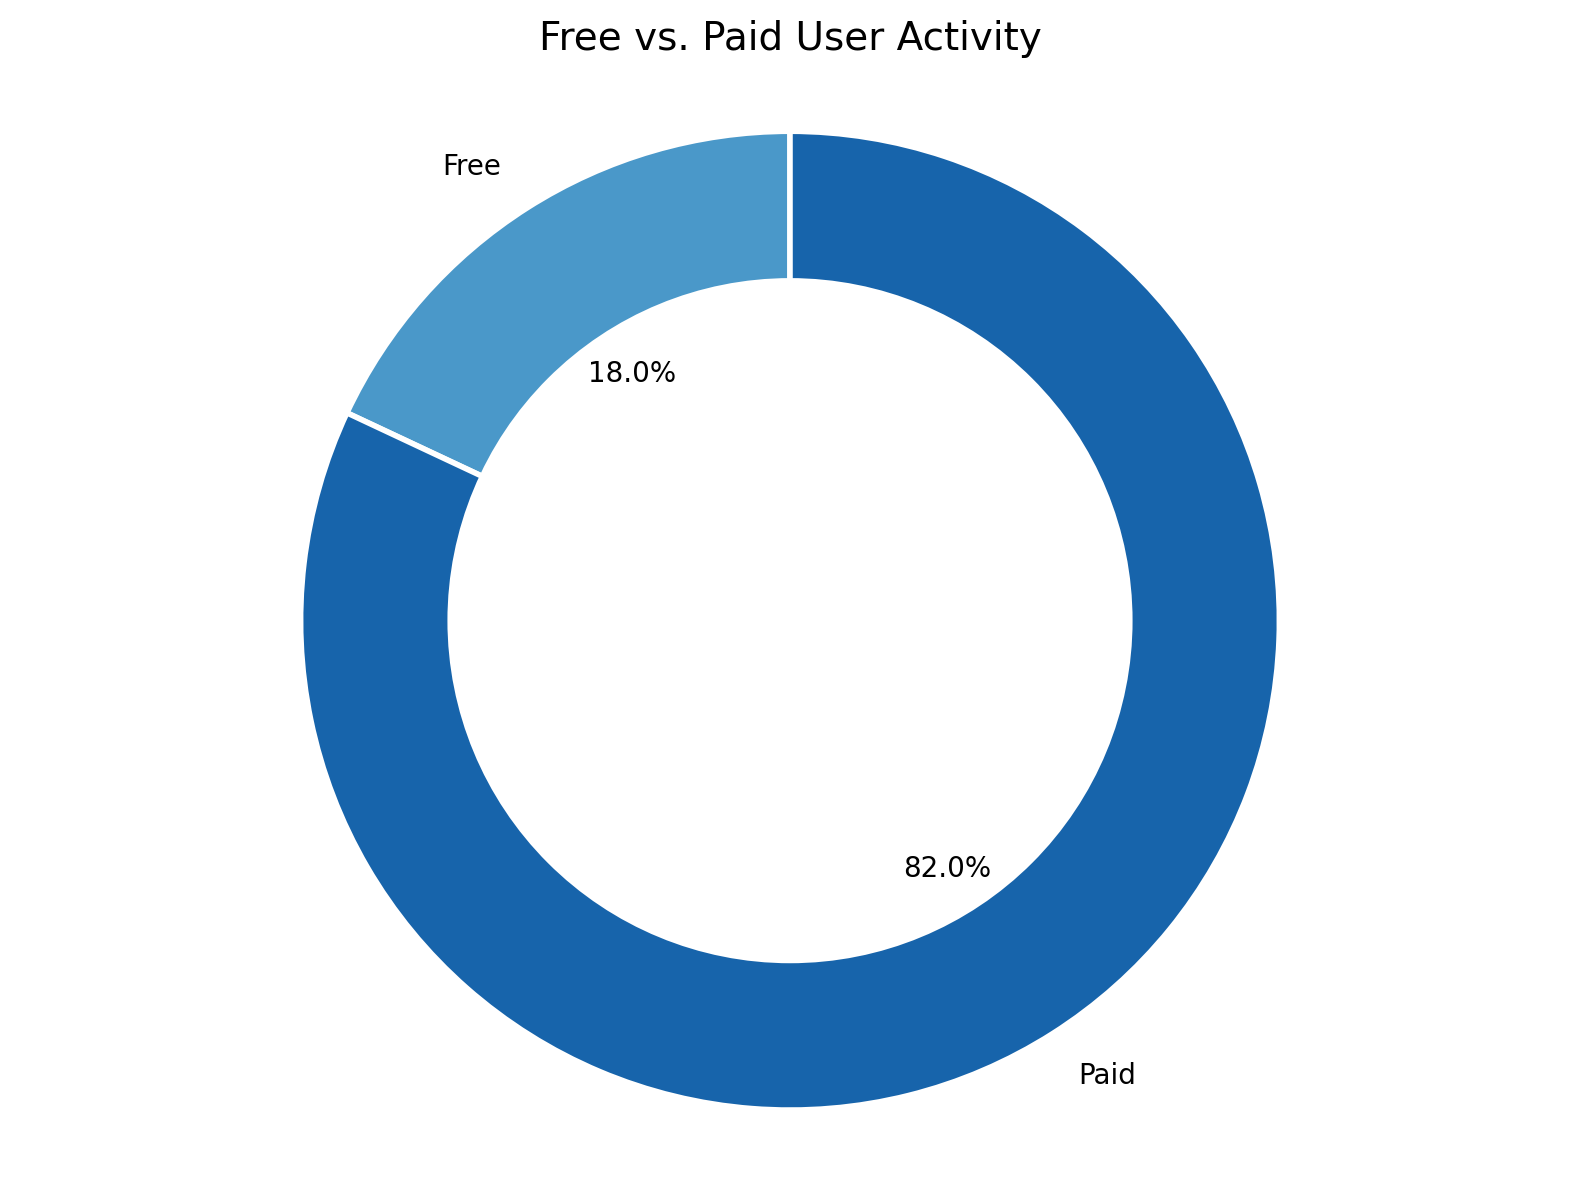

In [4]:
# Free vs. Paid user Activity
from matplotlib.patches import Circle

free_paid_usage = run_query("""
    SELECT level,
        COUNT(*) AS play_count
    FROM songplays
    GROUP BY level;
""")

plt.figure(figsize=(8, 6))

labels = free_paid_usage['level'].str.title()
sizes = free_paid_usage['play_count']
colors = sns.color_palette('Blues', n_colors=len(free_paid_usage) + 2)[2:]

# Draw the standard pie chart
plt.pie(
    sizes, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Draw a white circle in the center to make it a donut chart
centre_circle = Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Free vs. Paid User Activity', fontsize=14, pad=12)
plt.axis('equal')
plt.tight_layout()
plt.show()

In [5]:
# Most Active Users
active_users = run_query("""
    SELECT u.user_id,
           u.first_name || ' ' || u.last_name AS full_name,
           u.level,
           COUNT(*) AS play_count
    FROM songplays sp
    JOIN users u ON sp.user_id = u.user_id
    GROUP BY u.user_id, u.first_name, u.last_name, u.level
    ORDER BY play_count DESC
    LIMIT 10;
""")

active_users

,user_id,full_name,level,play_count
0,49,Chloe Cuevas,paid,689
1,80,Tegan Levine,paid,665
2,97,Kate Harrell,paid,557
3,15,Lily Koch,paid,463
4,44,Aleena Kirby,paid,397
5,29,Jacqueline Lynch,paid,346
6,24,Layla Griffin,paid,321
7,73,Jacob Klein,paid,289
8,88,Mohammad Rodriguez,paid,270
9,36,Matthew Jones,paid,248


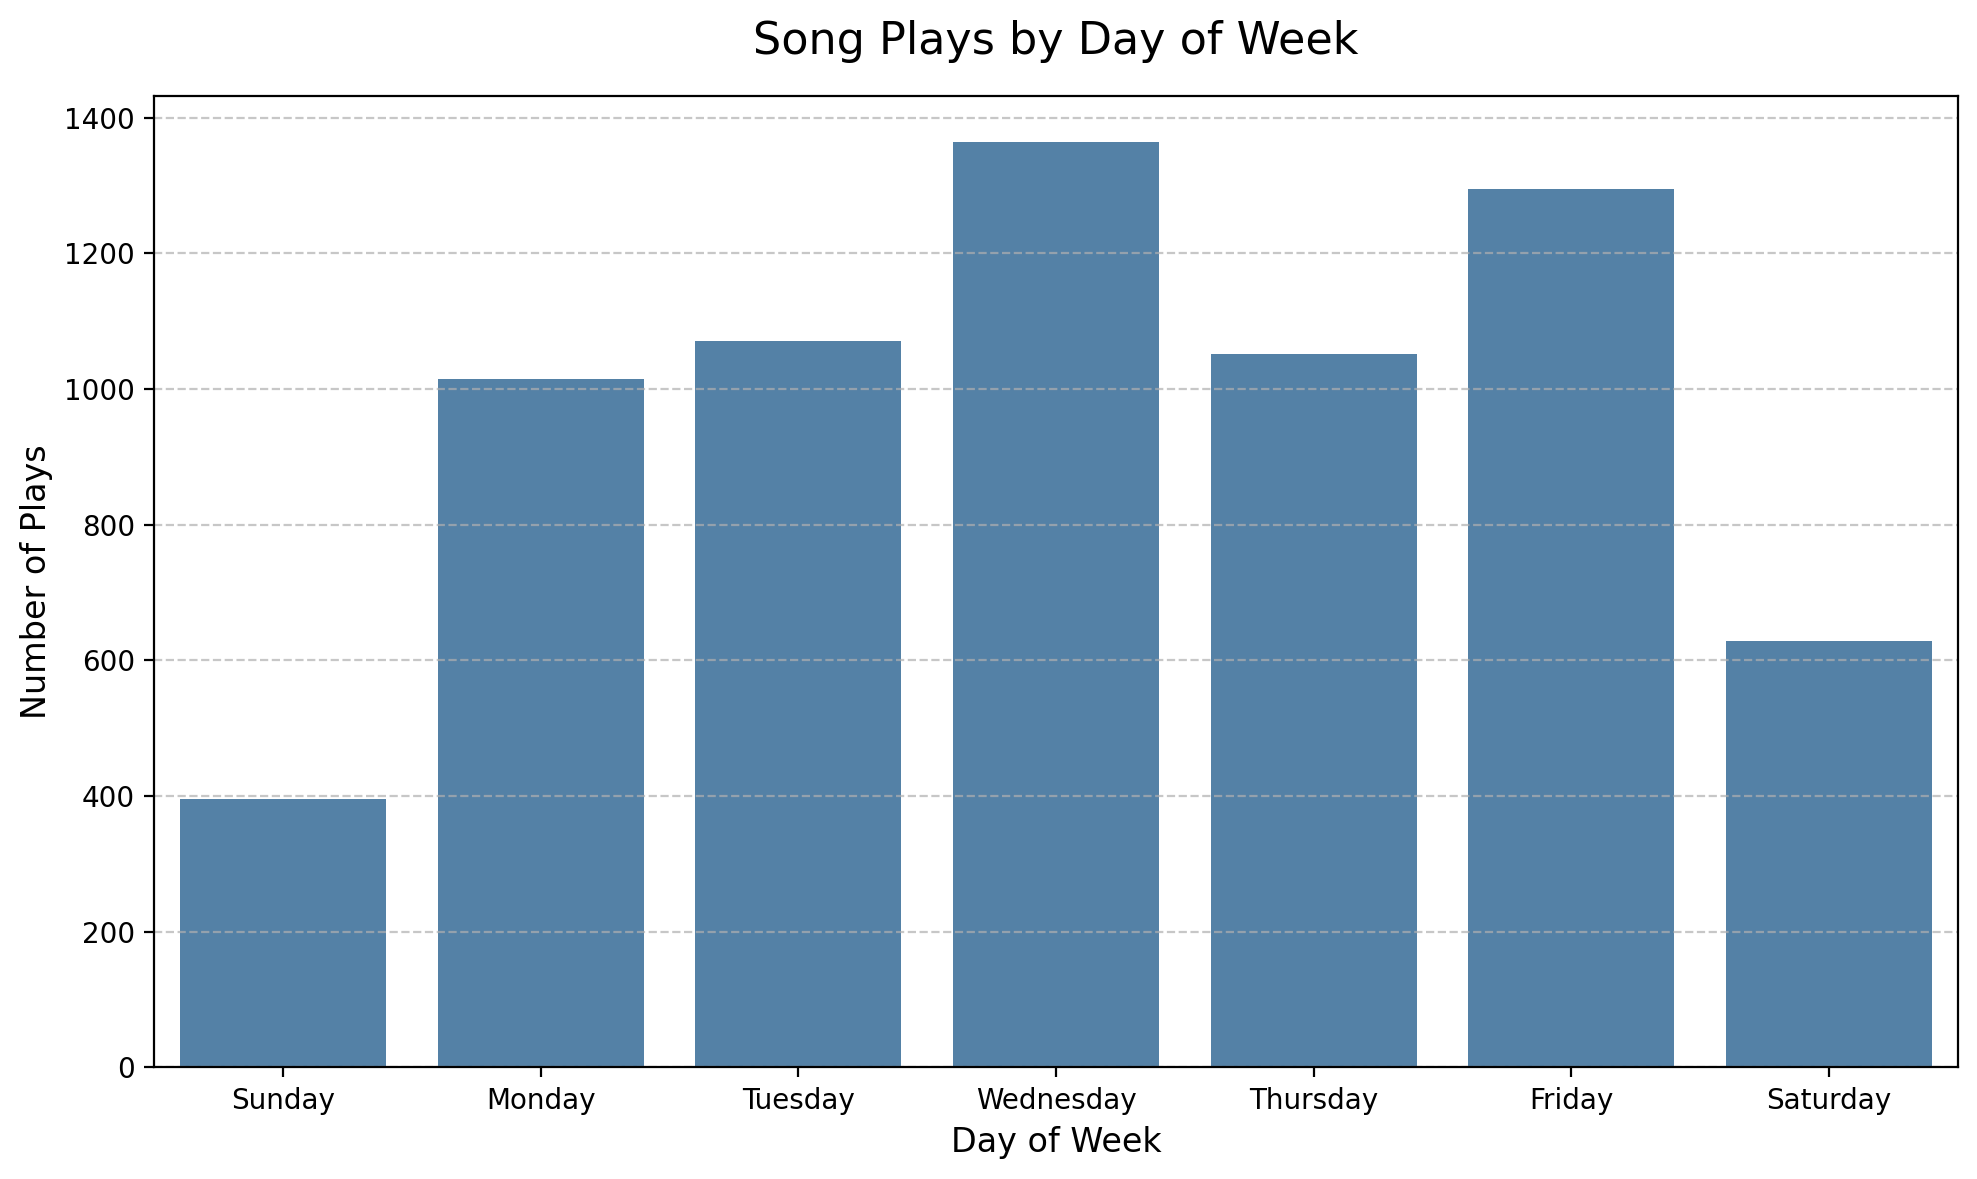

In [6]:
# Plays by Day of Week
weekday_usage = run_query("""
    SELECT t.weekday,
           CASE t.weekday
               WHEN 0 THEN 'Sunday'
               WHEN 1 THEN 'Monday'
               WHEN 2 THEN 'Tuesday'
               WHEN 3 THEN 'Wednesday'
               WHEN 4 THEN 'Thursday'
               WHEN 5 THEN 'Friday'
               WHEN 6 THEN 'Saturday'
           END AS day_name,
           COUNT(*) AS play_count
    FROM songplays sp
    JOIN time t ON sp.start_time = t.start_time
    GROUP BY t.weekday
    ORDER BY t.weekday;
""")

plt.figure(figsize=(10, 6))

# Create a Seaborn barplot
sns.barplot(
    data=weekday_usage,
    x='day_name',
    y='play_count',
    color='steelblue'
)

# Set the title and labels
plt.title('Song Plays by Day of Week', fontsize=16, pad=15)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Number of Plays', fontsize=12)

# Add gridlines on the y-axis for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout and display
plt.tight_layout()
plt.show()

In [7]:
conn.close()
print("Connection closed.")

Connection closed.
